# Step 2c — Is the brightening a confound?

Spec: `CLAUDE.md` §6 step 2c (added 2026-09-16). Aimed at the Step 2b confound, not at rescuing the
design.

Step 2b found flooded units brightening by a median 2.66 dB in VV (separation 0.72) while the
spec's rule looks for a drop — but those units were **already 2.55 dB brighter before the event**
(separation 0.77). Two tests:

1. **Position rather than flooding?** Across all units, is pre-event VV explained by distance to the
   river, elevation and field size? Do the flooded and dry groups differ on those variables
   independently of flooding? The change comparison is then repeated on dry units **matched** to the
   flooded group on elevation and distance.
2. **Does the brightening persist?** The 19 March post value against the 31 March acquisition on the
   same track. Sediment deposition or damaged mulch should persist for weeks; transient standing
   water should not.

**CHECKPOINT:** correlations, matched comparison, persistence test, verdict. Stop before Step 3.

In [1]:
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C

ee.Initialize(project=C.EE_PROJECT)

ELEV = "USGS/3DEP/10m_collection"   # ImageCollection; mosaicked below
RIVERS = "WWF/HydroSHEDS/v1/FreeFlowingRivers"
PRE_WINDOW = ("2023-02-01", "2023-03-09")
LATER_DATE = "2023-03-31"        # next pass on the same track after 19 March
CLEAR_MIN, FLOODED_MIN, DRY_MAX = 0.5, 0.3, 0.05

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
units_fc = ee.FeatureCollection(C.UNITS_ASSET).filter(ee.Filter.eq("is_unit", 1))

vals = pd.read_csv(C.DERIVED / "02b_field_backscatter.csv")
vals["field_id"] = vals.field_id.astype(str)
u = vals[vals.crop_class == "T20"].copy()
units_tbl = pd.read_csv(C.DERIVED / "01_units_dwr.csv")
units_tbl["unit_id"] = units_tbl.unit_id.astype(str)
u = u.merge(units_tbl[["unit_id", "ACRES", "lon", "lat", "COUNTY"]],
            left_on="field_id", right_on="unit_id", how="left")
N_UNITS = len(u)

track_tbl = pd.read_csv(C.DERIVED / "02_s1_track_coverage.csv")
row = track_tbl[track_tbl.covers_units & (track_tbl.pre_scenes >= 2)].sort_values("days_after_peak").iloc[0]
PASS, REL_ORBIT, POST_DATE = row["pass"], int(row.rel_orbit), row.post_date
print(f"n units = {N_UNITS} | Sentinel-1 {PASS} relative orbit {REL_ORBIT}: pre "
      f"{PRE_WINDOW[0]} to 2023-03-08, post {POST_DATE}, persistence check {LATER_DATE}")
print(f"datasets: {C.S1}, {ELEV}, {RIVERS}, {C.UNITS_ASSET}")


def separation(flood, dry):
    # P(flooded value < dry value) from ranks; 0.5 = no separation
    x = np.concatenate([flood, dry])
    r = pd.Series(x).rank().to_numpy()
    n1, n2 = len(flood), len(dry)
    return 1 - (r[:n1].sum() - n1 * (n1 + 1) / 2) / (n1 * n2)

n units = 1320 | Sentinel-1 ASCENDING relative orbit 35: pre 2023-02-01 to 2023-03-08, post 2023-03-19, persistence check 2023-03-31
datasets: COPERNICUS/S1_GRD, USGS/3DEP/10m_collection, WWF/HydroSHEDS/v1/FreeFlowingRivers, projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## Position variables: elevation, distance to river, field size

In [2]:
rivers = ee.FeatureCollection(RIVERS).filterBounds(region)
riv = gpd.GeoDataFrame.from_features(rivers.getInfo()["features"], crs="EPSG:4326")
riv = riv.to_crs(C.GRID_CRS)
print(f"river reaches from {RIVERS} intersecting the study area: {len(riv)}")

cent = gpd.GeoDataFrame(u[["field_id"]], crs="EPSG:4326",
                        geometry=gpd.points_from_xy(u.lon, u.lat)).to_crs(C.GRID_CRS)
u["km_to_river"] = cent.geometry.apply(lambda g: riv.distance(g).min()) / 1000

elev_img = ee.ImageCollection(ELEV).mosaic().select("elevation").rename("elev_m")
parts = []
ids = u.field_id.tolist()
for i in range(0, len(ids), 200):
    chunk = units_fc.filter(ee.Filter.inList("unit_id", ids[i:i + 200]))
    red = elev_img.reduceRegions(chunk, ee.Reducer.mean(), scale=10, tileScale=16)
    parts += [f["properties"] for f in
              red.select(["unit_id", "mean"], retainGeometry=False).getInfo()["features"]]
el = pd.DataFrame(parts).rename(columns={"mean": "elev_m", "unit_id": "field_id"})
el["field_id"] = el.field_id.astype(str)
u = u.merge(el, on="field_id", how="left")
print(f"elevation: median {u.elev_m.median():.1f} m, range {u.elev_m.min():.0f} to {u.elev_m.max():.0f} m")
print(f"distance to a mapped river: median {u.km_to_river.median():.2f} km, "
      f"range {u.km_to_river.min():.2f} to {u.km_to_river.max():.2f} km")
print(f"NOTE: {RIVERS} is a coarse global network; distances are approximate and mainly separate "
      f"valley-floor fields from upland ones.")
print(f"n units = {N_UNITS} | date window: static layers | datasets: {ELEV}, {RIVERS}")

river reaches from WWF/HydroSHEDS/v1/FreeFlowingRivers intersecting the study area: 508


elevation: median 33.1 m, range -1 to 210 m
distance to a mapped river: median 0.95 km, range 0.01 to 4.06 km
NOTE: WWF/HydroSHEDS/v1/FreeFlowingRivers is a coarse global network; distances are approximate and mainly separate valley-floor fields from upland ones.
n units = 1320 | date window: static layers | datasets: USGS/3DEP/10m_collection, WWF/HydroSHEDS/v1/FreeFlowingRivers


## 1. Is pre-event brightness explained by position?

In [3]:
corr = u[["pre_vv", "pre_vh", "base_vv", "base_vh", "elev_m", "km_to_river", "ACRES"]].corr(
    method="spearman").loc[["pre_vv", "pre_vh", "base_vv", "base_vh"],
                           ["elev_m", "km_to_river", "ACRES"]]
print("Spearman rank correlation across all units:")
print(corr.round(3).to_string())
print()

clear = u[u.clear15 >= CLEAR_MIN]
flood = clear[clear.opt15 >= FLOODED_MIN]
dry = clear[clear.opt15 <= DRY_MAX]
rows = []
for col, label in [("elev_m", "elevation (m)"), ("km_to_river", "distance to river (km)"),
                   ("ACRES", "field size (acres)"), ("pre_vv", "pre-event VV (dB)"),
                   ("base_vh", "baseline VH water-like fraction")]:
    a, b = flood[col].dropna().to_numpy(), dry[col].dropna().to_numpy()
    rows.append({"variable": label, "flooded median": np.median(a), "dry median": np.median(b),
                 "difference": np.median(a) - np.median(b),
                 "separation (0.5 = none)": max(separation(a, b), 1 - separation(a, b))})
print(f"Flooded (n = {len(flood)}) vs dry (n = {len(dry)}) units, clear view on 15 March:")
print(pd.DataFrame(rows).round(2).to_string(index=False))
print()
print("If the flooded group sits lower and closer to the river, its pre-event brightness may be a")
print("property of position rather than evidence about flooding.")
print(f"n units = {N_UNITS} | date window: pre {PRE_WINDOW[0]} to 2023-03-08 | datasets: {C.S1}, "
      f"{ELEV}, {RIVERS}")

Spearman rank correlation across all units:
         elev_m  km_to_river  ACRES
pre_vv   -0.107       -0.171  0.003
pre_vh    0.035       -0.130 -0.186
base_vv   0.068        0.159  0.081
base_vh  -0.027        0.133  0.177

Flooded (n = 18) vs dry (n = 719) units, clear view on 15 March:
                       variable  flooded median  dry median  difference  separation (0.5 = none)
                  elevation (m)            6.61       29.63      -23.02                     0.91
         distance to river (km)            0.80        0.78        0.02                     0.53
             field size (acres)           11.85       10.23        1.61                     0.57
              pre-event VV (dB)          -10.01      -12.56        2.55                     0.77
baseline VH water-like fraction            0.55        0.49        0.06                     0.54

If the flooded group sits lower and closer to the river, its pre-event brightness may be a
property of position rather than evi

## 2. Matched comparison: dry units matched on elevation and distance

In [4]:
rng = np.random.default_rng(0)
pool = dry.dropna(subset=["elev_m", "km_to_river"]).copy()
matched_idx, used = [], set()
for _, f in flood.dropna(subset=["elev_m", "km_to_river"]).iterrows():
    cand = pool[~pool.index.isin(used)]
    if cand.empty:
        break
    # nearest dry unit in standardised elevation and distance space, 3 per flooded unit
    d = (((cand.elev_m - f.elev_m) / max(pool.elev_m.std(), 1e-6)) ** 2
         + ((cand.km_to_river - f.km_to_river) / max(pool.km_to_river.std(), 1e-6)) ** 2) ** 0.5
    take = d.nsmallest(3).index.tolist()
    matched_idx += take
    used.update(take)
matched = dry.loc[matched_idx]
print(f"matched dry units: {len(matched)} (3 per flooded unit where available)")
print(pd.DataFrame([
    {"group": "flooded", "n": len(flood), "elev_m": flood.elev_m.median(),
     "km_to_river": flood.km_to_river.median(), "pre_vv": flood.pre_vv.median(),
     "d_vv": flood.d_vv.median()},
    {"group": "dry, all", "n": len(dry), "elev_m": dry.elev_m.median(),
     "km_to_river": dry.km_to_river.median(), "pre_vv": dry.pre_vv.median(),
     "d_vv": dry.d_vv.median()},
    {"group": "dry, matched", "n": len(matched), "elev_m": matched.elev_m.median(),
     "km_to_river": matched.km_to_river.median(), "pre_vv": matched.pre_vv.median(),
     "d_vv": matched.d_vv.median()},
]).round(2).to_string(index=False))
print()
for col, label in [("pre_vv", "pre-event VV"), ("d_vv", "VV change")]:
    s_all = separation(flood[col].dropna().to_numpy(), dry[col].dropna().to_numpy())
    s_mat = separation(flood[col].dropna().to_numpy(), matched[col].dropna().to_numpy())
    print(f"{label}: separation against all dry units {max(s_all, 1 - s_all):.2f}, "
          f"against matched dry units {max(s_mat, 1 - s_mat):.2f}")
print()
print("If the change separation survives matching while the pre-event separation shrinks, the")
print("brightening is about flooding. If both survive unchanged, position explains them.")
print(f"n units = {N_UNITS} | date window: pre {PRE_WINDOW[0]} to 2023-03-08; post {POST_DATE} | "
      f"datasets: {C.S1}, {ELEV}, {RIVERS}")

matched dry units: 54 (3 per flooded unit where available)
       group   n  elev_m  km_to_river  pre_vv  d_vv
     flooded  18    6.61         0.80  -10.01  3.22
    dry, all 719   29.63         0.78  -12.56  0.56
dry, matched  54    6.91         0.75  -12.18  0.40

pre-event VV: separation against all dry units 0.77, against matched dry units 0.68
VV change: separation against all dry units 0.72, against matched dry units 0.74

If the change separation survives matching while the pre-event separation shrinks, the
brightening is about flooding. If both survive unchanged, position explains them.
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; post 2023-03-19 | datasets: COPERNICUS/S1_GRD, USGS/3DEP/10m_collection, WWF/HydroSHEDS/v1/FreeFlowingRivers


## 3. Does the brightening persist to 31 March?

In [5]:
s1 = (ee.ImageCollection(C.S1).filterBounds(region)
      .filter(ee.Filter.eq("instrumentMode", "IW"))
      .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
      .filter(ee.Filter.eq("orbitProperties_pass", PASS))
      .filter(ee.Filter.eq("relativeOrbitNumber_start", REL_ORBIT)))
kernel = ee.Kernel.square(radius=1, units="pixels")
later = (s1.filterDate(LATER_DATE, ee.Date(LATER_DATE).advance(1, "day"))
         .select(["VV", "VH"]).mosaic().focal_mean(kernel=kernel))
print(f"{LATER_DATE} scenes on this track: "
      f"{s1.filterDate(LATER_DATE, ee.Date(LATER_DATE).advance(1, 'day')).size().getInfo()}")

LATER_CSV = C.DERIVED / "02c_units_later_pass.csv"
if LATER_CSV.exists():
    lat = pd.read_csv(LATER_CSV)
    lat["field_id"] = lat.field_id.astype(str)
    print(f"Loaded cached {LATER_CSV.name}")
else:
    parts = []
    for i in range(0, len(ids), 200):
        chunk = units_fc.filter(ee.Filter.inList("unit_id", ids[i:i + 200]))
        red = (later.select("VV").rename("vv31").addBands(later.select("VH").rename("vh31"))
               .reduceRegions(chunk, ee.Reducer.mean(), scale=10, tileScale=16))
        parts += [f["properties"] for f in
                  red.select(["unit_id", "vv31", "vh31"], retainGeometry=False).getInfo()["features"]]
    lat = pd.DataFrame(parts).rename(columns={"unit_id": "field_id"})
    lat["field_id"] = lat.field_id.astype(str)
    lat.to_csv(LATER_CSV, index=False)
    print(f"Wrote {LATER_CSV.name}")

u = u.merge(lat, on="field_id", how="left")
u["d_vv_31"] = u.vv31 - u.pre_vv
clear = u[u.clear15 >= CLEAR_MIN]
flood = clear[clear.opt15 >= FLOODED_MIN]
dry = clear[clear.opt15 <= DRY_MAX]

rows = []
for col, when in [("d_vv", f"{POST_DATE} (8 days after)"), ("d_vv_31", f"{LATER_DATE} (20 days after)")]:
    a, b = flood[col].dropna().to_numpy(), dry[col].dropna().to_numpy()
    s_ = separation(a, b)
    rows.append({"VV change vs pre-event": when, "flooded median": np.median(a),
                 "dry median": np.median(b), "difference": np.median(a) - np.median(b),
                 "separation": max(s_, 1 - s_),
                 "direction": "flooded brighter" if np.median(a) > np.median(b) else "flooded darker"})
persist = pd.DataFrame(rows)
print()
print(persist.round(2).to_string(index=False))
persist.to_csv(C.DERIVED / "02c_persistence.csv", index=False)
u.to_csv(C.DERIVED / "02c_units_confound.csv", index=False)
print("Wrote 02c_persistence.csv and 02c_units_confound.csv")

d8 = persist.loc[0, "difference"]
d20 = persist.loc[1, "difference"]
print()
print("VERDICT")
print(f"  Brightening against dry units: {d8:+.2f} dB at 8 days, {d20:+.2f} dB at 20 days "
      f"({100 * d20 / d8:.0f}% retained)" if abs(d8) > 0.01 else "  no measurable brightening")
if abs(d20) >= 0.5 * abs(d8) and d20 * d8 > 0:
    print("  The difference persists to 31 March, which is consistent with a lasting surface change")
    print("  such as sediment deposition or damaged mulch, and not with transient standing water.")
else:
    print("  The difference fades by 31 March, which is what transient standing water would do and")
    print("  not what sediment deposition or mulch damage would do.")
print(f"n units = {N_UNITS} | date window: pre {PRE_WINDOW[0]} to 2023-03-08; posts {POST_DATE} and "
      f"{LATER_DATE} | datasets: {C.S1}, {C.S2} (groups)")

2023-03-31 scenes on this track: 2
Loaded cached 02c_units_later_pass.csv

    VV change vs pre-event  flooded median  dry median  difference  separation        direction
 2023-03-19 (8 days after)            3.22        0.56        2.66        0.72 flooded brighter
2023-03-31 (20 days after)            2.53        0.90        1.64        0.79 flooded brighter
Wrote 02c_persistence.csv and 02c_units_confound.csv

VERDICT
  Brightening against dry units: +2.66 dB at 8 days, +1.64 dB at 20 days (62% retained)
  The difference persists to 31 March, which is consistent with a lasting surface change
  such as sediment deposition or damaged mulch, and not with transient standing water.
n units = 1320 | date window: pre 2023-02-01 to 2023-03-08; posts 2023-03-19 and 2023-03-31 | datasets: COPERNICUS/S1_GRD, COPERNICUS/S2_SR_HARMONIZED (groups)


## Figure — position confound and persistence

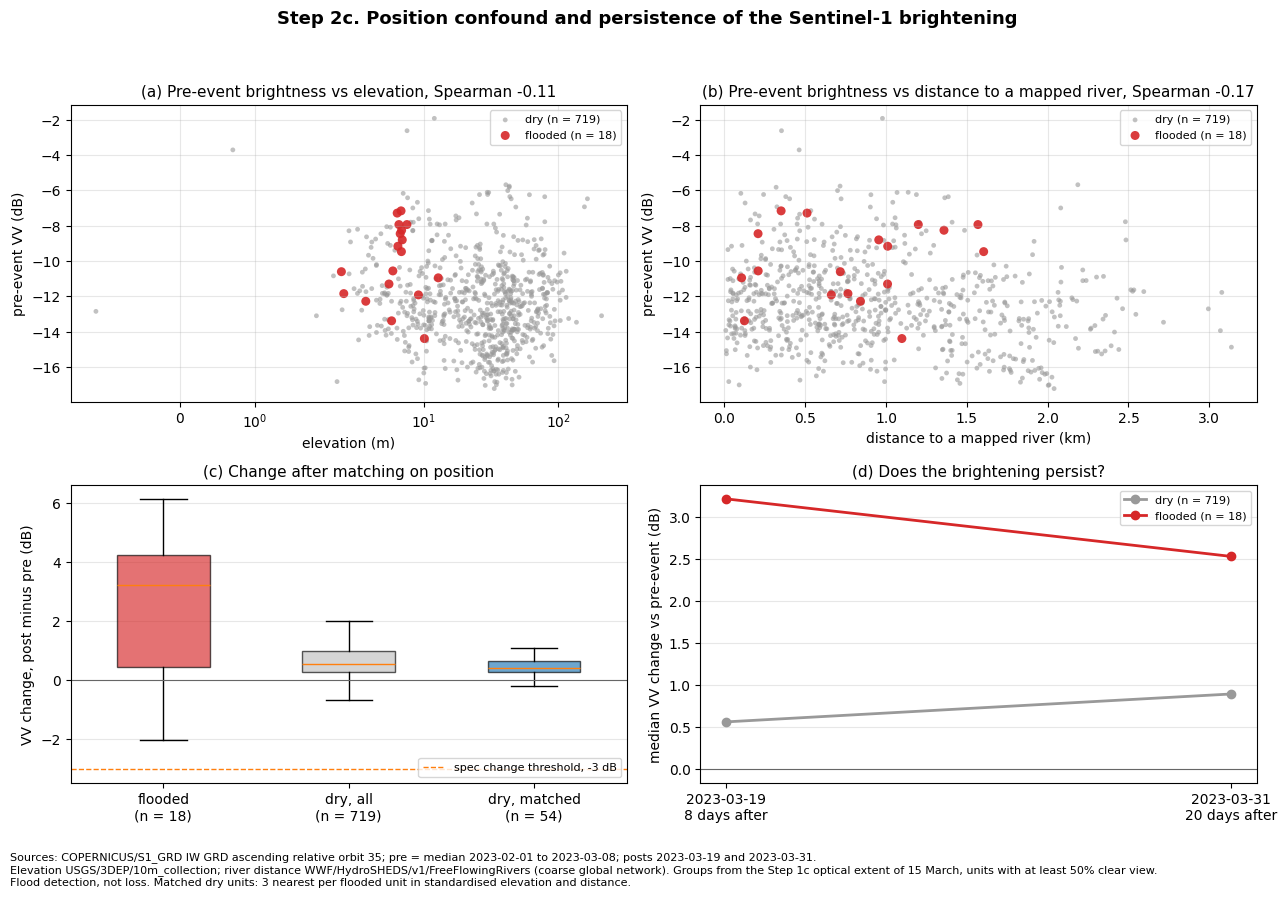

Saved supp_confound_tests.png
n units = 1320 | date window: posts 2023-03-19 and 2023-03-31 | datasets: COPERNICUS/S1_GRD, USGS/3DEP/10m_collection, WWF/HydroSHEDS/v1/FreeFlowingRivers


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
groups = [("dry", dry, "0.6", 12), ("flooded", flood, "tab:red", 42)]

for ax, xcol, xlabel, letter in [(axes[0, 0], "elev_m", "elevation (m)", "a"),
                                 (axes[0, 1], "km_to_river", "distance to a mapped river (km)", "b")]:
    for name, g, color, size in groups:
        ax.scatter(g[xcol], g.pre_vv, s=size, color=color, alpha=0.6 if name == "dry" else 0.9,
                   edgecolors="none", label=f"{name} (n = {len(g)})")
    r = u[["pre_vv", xcol]].corr(method="spearman").iloc[0, 1]
    ax.set_xlabel(xlabel)
    ax.set_ylabel("pre-event VV (dB)")
    ax.set_title(f"({letter}) Pre-event brightness vs {xlabel.split(' (')[0]}, Spearman {r:+.2f}",
                 fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    if xcol == "elev_m":
        ax.set_xscale("symlog")

ax = axes[1, 0]
data = [flood.d_vv.dropna(), dry.d_vv.dropna(), matched.d_vv.dropna()]
bp = ax.boxplot(data, tick_labels=[f"flooded\n(n = {len(data[0])})", f"dry, all\n(n = {len(data[1])})",
                                   f"dry, matched\n(n = {len(data[2])})"],
                showfliers=False, patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], ["tab:red", "0.75", "tab:blue"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.65)
ax.axhline(0, color="0.4", lw=0.8)
ax.axhline(-3, color="tab:orange", ls="--", lw=1, label="spec change threshold, -3 dB")
ax.set_ylabel("VV change, post minus pre (dB)")
ax.set_title("(c) Change after matching on position", fontsize=11)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1, 1]
for name, g, color, _ in groups:
    ax.plot([8, 20], [g.d_vv.median(), g.d_vv_31.median()], marker="o", color=color, lw=2,
            label=f"{name} (n = {len(g)})")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xticks([8, 20])
ax.set_xticklabels([f"{POST_DATE}\n8 days after", f"{LATER_DATE}\n20 days after"])
ax.set_ylabel("median VV change vs pre-event (dB)")
ax.set_title("(d) Does the brightening persist?", fontsize=11)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)

fig.suptitle("Step 2c. Position confound and persistence of the Sentinel-1 brightening",
             fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S1} IW GRD {PASS.lower()} relative orbit {REL_ORBIT}; pre = median "
         f"{PRE_WINDOW[0]} to 2023-03-08; posts {POST_DATE} and {LATER_DATE}.\n"
         f"Elevation {ELEV}; river distance {RIVERS} (coarse global network). Groups from the Step 1c "
         f"optical extent of 15 March, units with at least {CLEAR_MIN:.0%} clear view.\n"
         f"Flood detection, not loss. Matched dry units: 3 nearest per flooded unit in standardised "
         f"elevation and distance.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
FIG = C.FIGURES / "supp_confound_tests.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
print(f"n units = {N_UNITS} | date window: posts {POST_DATE} and {LATER_DATE} | datasets: {C.S1}, "
      f"{ELEV}, {RIVERS}")